# Marketing Analytics — Final Notebook (Fixed)
**Generated:** 2025-08-18

This notebook loads raw e-commerce data (non-contractual, continuous purchases) and produces:
- Core KPIs (AOV, CAC, ROAS)
- Cohort retention & LTV tables
- Probabilistic CLV (BG/NBD + Gamma-Gamma)
- Survival (Kaplan–Meier)
- Basic seasonality chart

> **Fix applied:** removed duplicate `month_str` columns and made plotting robust.


In [1]:

# === 1) Setup & Imports ===
import os, math, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

DATA_DIR = os.getenv("DATA_DIR", "./Data")
OUTPUT_DIR = os.getenv("OUTPUT_DIR", "./outputs")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_DIR: ./Data
OUTPUT_DIR: ./outputs


## 2) Load Data

In [2]:

# Required files (place them in ./Data)
# - Online_Sales.csv
# - CustomersData.xlsx
# - Discount_Coupon.csv
# - Marketing_Spend.csv
# - Tax_amount.xlsx

def _read_csv(path, **kw):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, **kw)

def _read_excel(path, **kw):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_excel(path, **kw)

df_sales      = _read_csv(os.path.join(DATA_DIR, "Online_Sales.csv"))
df_customers  = _read_excel(os.path.join(DATA_DIR, "CustomersData.xlsx"))
df_discount   = _read_csv(os.path.join(DATA_DIR, "Discount_Coupon.csv"))
df_marketing  = _read_csv(os.path.join(DATA_DIR, "Marketing_Spend.csv"))
df_tax        = _read_excel(os.path.join(DATA_DIR, "Tax_amount.xlsx"))

print("Shapes:",
      "sales", df_sales.shape,
      "customers", df_customers.shape,
      "discount", df_discount.shape,
      "marketing", df_marketing.shape,
      "tax", df_tax.shape, sep=" | ")
df_sales.head(3)


Shapes: | sales | (52924, 10) | customers | (1468, 4) | discount | (204, 4) | marketing | (365, 3) | tax | (20, 2)


,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,avg_price,delivery_charges,coupon_status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used


## 3) Cleaning & Mart Build

In [3]:

# Parse dates
df_sales['transaction_date'] = pd.to_datetime(df_sales['transaction_date'])

# Normalize discount table
_month_map = {m.lower()[:3]: i for i, m in enumerate(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], start=1)}
df_discount['month_num'] = df_discount['month'].str.lower().str[:3].map(_month_map)

# Compute revenue per row (gross minus discount plus delivery, excl tax for net revenue)
row_gross = df_sales['quantity'] * df_sales['avg_price']
sales = df_sales.copy()
sales['month_num'] = sales['transaction_date'].dt.month
sales = sales.merge(df_discount[['month_num','product_category','discount_pct']],
                    on=['month_num','product_category'], how='left')
sales['discount_pct'] = sales['discount_pct'].fillna(0.0)

# Join tax by product_category
sales = sales.merge(df_tax[['product_category','gst']].rename(columns={'gst':'gst_rate'}),
                    on='product_category', how='left')
sales['gst_rate'] = sales['gst_rate'].fillna(0.0)

# Net subtotal, pre-tax, gst, invoice
sales['gross_sales']   = row_gross
sales['discount_amt']  = sales['gross_sales'] * (sales['discount_pct']/100.0)
sales['net_subtotal']  = sales['gross_sales'] - sales['discount_amt']
sales['pre_tax_total'] = sales['net_subtotal'] + sales['delivery_charges']
sales['gst_amount']    = sales['pre_tax_total'] * sales['gst_rate']
sales['invoice_value'] = sales['pre_tax_total'] + sales['gst_amount']
sales['net_revenue']   = sales['pre_tax_total']  # ex-GST

# Customer join (gender/location/tenure)
sales = sales.merge(df_customers.rename(columns={'gender':'customer_gender','location':'customer_location','tenure_months':'customer_tenure_months'}),
                    on='customer_id', how='left')

# Marketing spend per day to month_str
df_marketing['date'] = pd.to_datetime(df_marketing['date'])
df_marketing['month_str'] = df_marketing['date'].dt.strftime('%Y-%m')
df_marketing['total_spend'] = df_marketing['offline_send'].fillna(0) + df_marketing['online_spend'].fillna(0)

# Add calendar features
sales['transaction_month'] = sales['transaction_date'].dt.month
sales['transaction_month_str'] = sales['transaction_date'].dt.strftime('%Y-%m')
sales['transaction_day_of_month'] = sales['transaction_date'].dt.day
sales['transaction_day_of_week']  = sales['transaction_date'].dt.day_name().str.lower()

# Final mart
mart_all = sales.copy()
print("mart_all_data shape:", mart_all.shape)
mart_all.head(3)


mart_all_data shape: (52924, 27)


,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,avg_price,delivery_charges,coupon_status,month_num,discount_pct,gst_rate,gross_sales,discount_amt,net_subtotal,pre_tax_total,gst_amount,invoice_value,net_revenue,customer_gender,customer_location,customer_tenure_months,transaction_month,transaction_month_str,transaction_day_of_month,transaction_day_of_week
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,10.0,0.1,153.71,15.371,138.339,144.839,14.4839,159.3229,144.839,M,Chicago,12,1,2019-01,1,tuesday
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,10.0,0.1,153.71,15.371,138.339,144.839,14.4839,159.3229,144.839,M,Chicago,12,1,2019-01,1,tuesday
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,10.0,0.1,2.05,0.205,1.845,8.345,0.8345,9.1795,8.345,M,Chicago,12,1,2019-01,1,tuesday


## 4) KPIs (Monthly revenue, orders, AOV, CAC, ROAS) — Fixed month key

In [4]:

# Monthly revenue & orders
monthly_rev = mart_all.groupby('transaction_month_str')['net_revenue'].sum().reset_index(name='total_revenue')
monthly_ord = mart_all.groupby('transaction_month_str')['transaction_id'].nunique().reset_index(name='order_count')

# New customers per month: first purchase month
first_purchase = mart_all.groupby('customer_id')['transaction_date'].min().dt.strftime('%Y-%m')
mart_all = mart_all.merge(first_purchase.rename('first_month'), on='customer_id', how='left')
new_cust = mart_all.drop_duplicates('customer_id').groupby('first_month')['customer_id'].count().reset_index(name='new_customers')

# Marketing spend by month (rename month to avoid duplicate column on merge)
monthly_spend = df_marketing.groupby('month_str')['total_spend'].sum().reset_index().rename(columns={'month_str':'spend_month'})

# Merge with explicit keys to avoid duplicate month columns
kpi = monthly_rev.merge(monthly_ord, on='transaction_month_str', how='outer')
kpi = kpi.merge(monthly_spend, left_on='transaction_month_str', right_on='spend_month', how='left')
kpi = kpi.merge(new_cust.rename(columns={'first_month':'signup_month'}), left_on='transaction_month_str', right_on='signup_month', how='left')
kpi = kpi.sort_values('transaction_month_str').reset_index(drop=True)

# KPIs
kpi['AOV']  = kpi['total_revenue'] / kpi['order_count']
kpi['CAC']  = kpi['total_spend'] / kpi['new_customers']
kpi['ROAS'] = kpi['total_revenue'] / kpi['total_spend']

# Keep a SINGLE month column
kpi['month_str'] = kpi['transaction_month_str']
kpi = kpi[['month_str','total_revenue','order_count','total_spend','new_customers','AOV','CAC','ROAS']]
kpi


,month_str,total_revenue,order_count,total_spend,new_customers,AOV,CAC,ROAS
0,2019-01,422761.417,2102,154928.95,215,201.123414,720.599767,2.728744
1,2019-02,298371.670,1664,137107.92,96,179.309898,1428.207500,2.176181
2,2019-03,306702.011,1991,122250.09,177,154.044204,690.678475,2.508808
3,2019-04,403415.743,1813,157026.83,163,222.512820,963.354785,2.569088
4,2019-05,288368.234,2034,118259.64,112,141.773960,1055.889643,2.438433
5,2019-06,262870.435,1940,134318.14,137,135.500224,980.424380,1.957073
6,2019-07,384410.641,2080,120217.85,94,184.812808,1278.913298,3.197617
7,2019-08,382420.734,2414,142904.15,135,158.417868,1058.549259,2.676065
8,2019-09,293614.648,1932,135514.54,78,151.974455,1737.365897,2.166665
9,2019-10,414835.173,2125,151224.65,87,195.216552,1738.214368,2.743172


### KPI Charts (robust plotting)

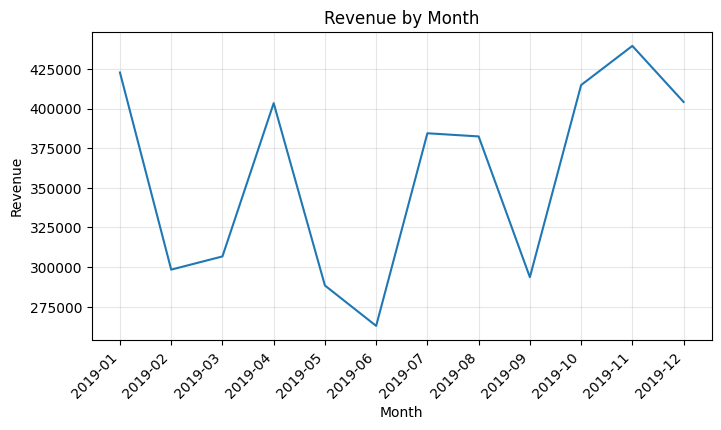

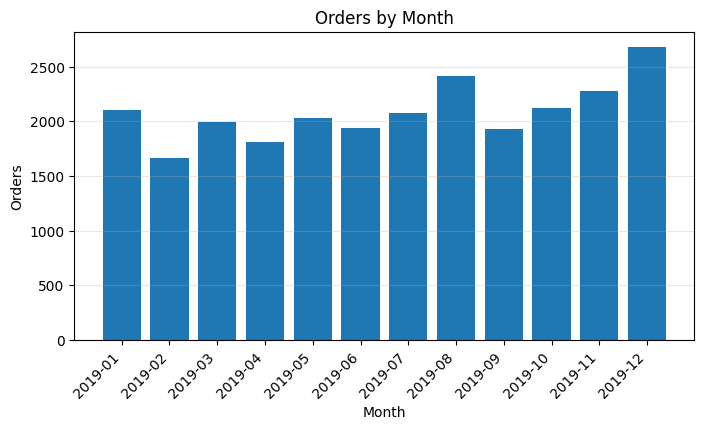

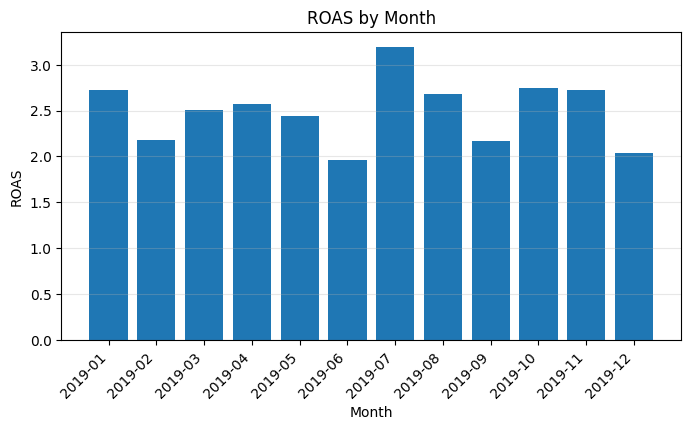

In [5]:

def _to_1d(values):
    # Accept Series/DataFrame/ndarray and return flat 1D array of strings or floats
    if isinstance(values, pd.DataFrame):
        values = values.iloc[:,0]
    if isinstance(values, pd.Series):
        return values.to_numpy()
    values = np.asarray(values)
    return values.ravel()

def line(x, y, title, xlabel, ylabel, rot=45, figsize=(8,4)):
    x_arr = _to_1d(x)
    y_arr = _to_1d(y).astype(float)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x_arr, y_arr)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if rot: plt.setp(ax.get_xticklabels(), rotation=rot, ha='right')
    plt.show()

def bar(x, y, title, xlabel, ylabel, rot=45, figsize=(8,4)):
    x_arr = _to_1d(x)
    y_arr = _to_1d(y).astype(float)
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x_arr, y_arr)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', alpha=0.3)
    if rot: plt.setp(ax.get_xticklabels(), rotation=rot, ha='right')
    plt.show()

line(kpi['month_str'], kpi['total_revenue'], "Revenue by Month", "Month", "Revenue")
bar(kpi['month_str'], kpi['order_count'], "Orders by Month", "Month", "Orders")
bar(kpi['month_str'], kpi['ROAS'], "ROAS by Month", "Month", "ROAS")


## 5) CLV (BG/NBD + Gamma-Gamma)

In [6]:

# Install lifetimes if needed (uncomment below when running locally)
# !pip -q install lifetimes

from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

tx = mart_all[['customer_id','transaction_date','net_revenue']].copy()
summary = summary_data_from_transaction_data(
    tx, customer_id_col='customer_id', datetime_col='transaction_date',
    monetary_value_col='net_revenue',
    observation_period_end=tx['transaction_date'].max()
)

# Fit models (penalizer helps convergence)
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Only freq > 0 for Gamma-Gamma
ret = summary[summary['frequency'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(ret['frequency'], ret['monetary_value'])

# Predict 6 months (180 days)
summary['pred_purchases_180d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, summary['frequency'], summary['recency'], summary['T']
)
summary['pred_avg_value'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)
summary['pred_ltv_180d'] = summary['pred_purchases_180d'] * summary['pred_avg_value']

summary[['pred_purchases_180d','pred_avg_value','pred_ltv_180d']].describe()


,pred_purchases_180d,pred_avg_value,pred_ltv_180d
count,1468.000000,1468.000000,1468.000000
mean,0.707964,628.998855,634.116105
std,0.798352,1455.726697,1863.851209
min,0.000019,-107.309000,-119.286754
25%,0.290916,-107.309000,-39.219034
50%,0.447640,-45.210291,-11.273573
75%,0.847045,864.198524,561.711817
max,10.546758,20893.200741,34495.823692


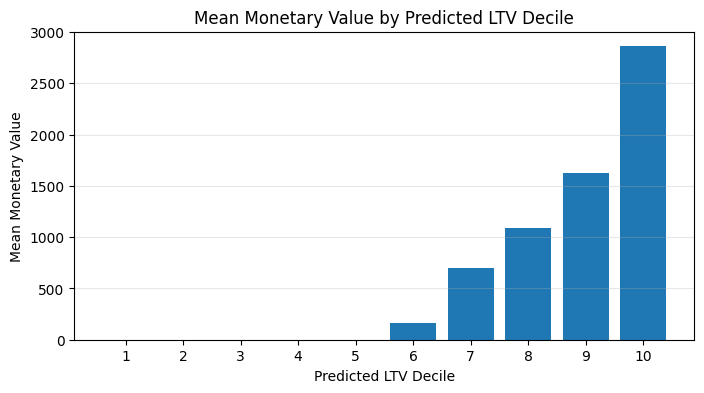

In [7]:

# Decile lift: sort by predicted LTV and check mean monetary value
tmp = summary.copy()
tmp = tmp.replace([np.inf, -np.inf], np.nan)
tmp = tmp.dropna(subset=['pred_ltv_180d'])
tmp['decile'] = pd.qcut(tmp['pred_ltv_180d'].rank(method='first'), 10, labels=False) + 1

dec = tmp.groupby('decile')['monetary_value'].mean().reset_index()
bar(dec['decile'].astype(str), dec['monetary_value'], "Mean Monetary Value by Predicted LTV Decile", "Predicted LTV Decile", "Mean Monetary Value", rot=0)


## 6) Cohort Analysis — Retention Matrix

In [8]:

orders = mart_all[['customer_id','transaction_date']].drop_duplicates().copy()
orders['order_month'] = pd.to_datetime(orders['transaction_date']).dt.to_period('M')
first_month = orders.groupby('customer_id')['order_month'].min().rename('signup_month')
orders = orders.merge(first_month, on='customer_id', how='left')
orders['cohort_index'] = (orders['order_month'] - orders['signup_month']).apply(lambda x: x.n)

cohort_counts = (orders
    .groupby(['signup_month','cohort_index'])['customer_id']
    .nunique()
    .reset_index()
    .pivot(index='signup_month', columns='cohort_index', values='customer_id')
    .fillna(0)
)
cohort_size = cohort_counts.iloc[:,0].replace(0, np.nan)
retention = (cohort_counts.divide(cohort_size, axis=0) * 100).round(1)
retention


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
signup_month,,,,,,,,,,,,
2019-01,100.0,6.0,11.2,15.8,10.7,20.5,16.3,21.9,10.7,13.0,9.3,15.8
2019-02,100.0,7.3,9.4,16.7,17.7,22.9,19.8,15.6,12.5,11.5,16.7,0.0
2019-03,100.0,10.2,19.8,14.1,18.1,18.6,12.4,12.4,8.5,10.7,0.0,0.0
2019-04,100.0,8.6,14.7,14.7,11.0,9.2,6.1,9.8,7.4,0.0,0.0,0.0
2019-05,100.0,10.7,8.0,11.6,8.9,11.6,12.5,7.1,0.0,0.0,0.0,0.0
2019-06,100.0,14.6,16.1,8.8,8.0,10.2,8.0,0.0,0.0,0.0,0.0,0.0
2019-07,100.0,13.8,4.3,6.4,11.7,9.6,0.0,0.0,0.0,0.0,0.0,0.0
2019-08,100.0,10.4,11.1,7.4,5.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-09,100.0,7.7,3.8,2.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


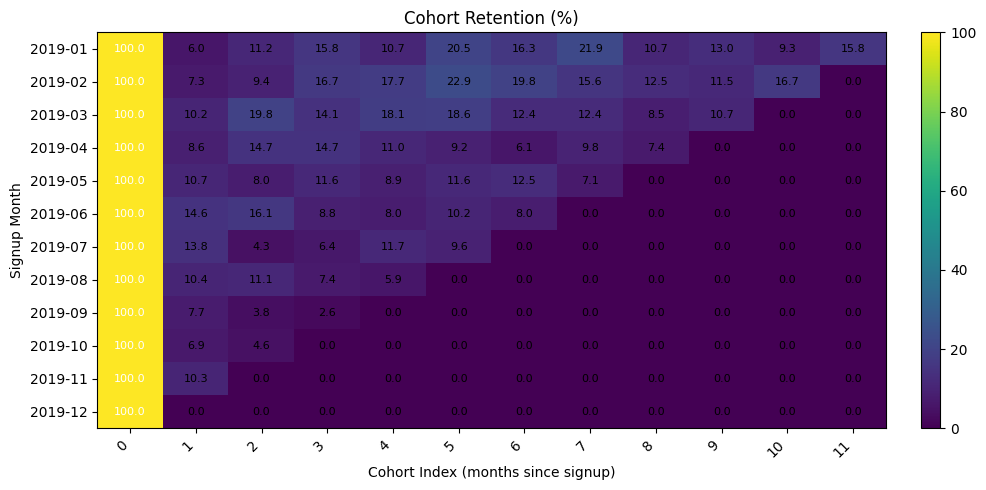

In [9]:

# Heatmap using matplotlib
M = retention.fillna(0).values
xt = retention.columns.astype(str).tolist()
yt = retention.index.astype(str).tolist()

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(M, aspect='auto')
ax.set_title('Cohort Retention (%)')
ax.set_xlabel('Cohort Index (months since signup)')
ax.set_ylabel('Signup Month')
ax.set_xticks(range(len(xt))); ax.set_xticklabels(xt, rotation=45, ha='right')
ax.set_yticks(range(len(yt))); ax.set_yticklabels(yt)
for (i,j), v in np.ndenumerate(M):
    ax.text(j, i, f"{v:.1f}", ha='center', va='center', fontsize=8, color='white' if v>50 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 7) Survival Analysis (Kaplan–Meier)

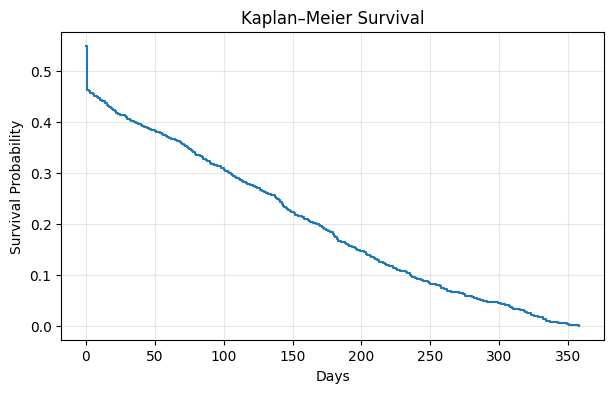

Median survival (days): 1.0


In [10]:

# !pip -q install lifelines
from lifelines import KaplanMeierFitter

cust = mart_all.groupby('customer_id').agg(
    first_purchase = ('transaction_date','min'),
    last_purchase  = ('transaction_date','max'),
    n_orders       = ('transaction_id','nunique')
).reset_index()

# Keep multi-buyers to get meaningful durations
cust = cust[cust['n_orders'] > 1].copy()
cust['lifespan_days'] = (cust['last_purchase'] - cust['first_purchase']).dt.days
# Treat customers whose last_purchase == global max as censored (still active)
obs_end = mart_all['transaction_date'].max()
cust['event_observed'] = (cust['last_purchase'] < obs_end).astype(int)

kmf = KaplanMeierFitter()
kmf.fit(durations=cust['lifespan_days'], event_observed=cust['event_observed'], label='Customer Survival')

fig, ax = plt.subplots(figsize=(7,4))
ax.step(kmf.survival_function_.index, kmf.survival_function_['Customer Survival'], where='post')
ax.set_title('Kaplan–Meier Survival'); ax.set_xlabel('Days'); ax.set_ylabel('Survival Probability'); ax.grid(True, alpha=0.3)
plt.show()

print("Median survival (days):", kmf.median_survival_time_)


## 8) Seasonality — Daily Revenue Line

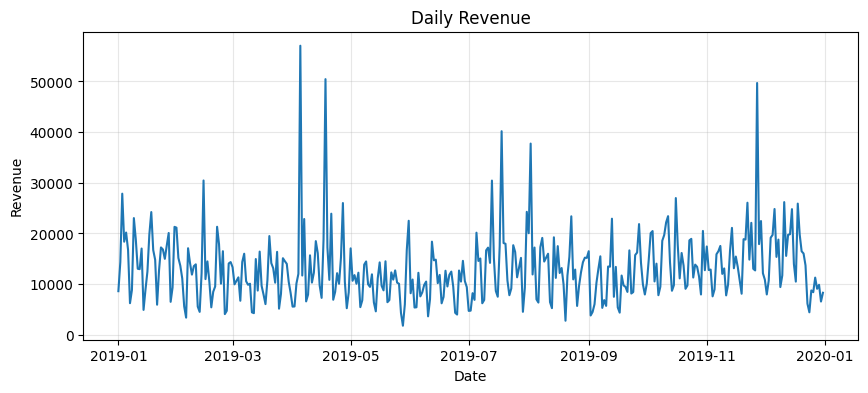

In [11]:

daily_rev = mart_all.groupby(pd.to_datetime(mart_all['transaction_date']).dt.date)['invoice_value'].sum().reset_index(name='revenue')
# Rename date col for plotting
daily_rev = daily_rev.rename(columns={daily_rev.columns[0]: 'date'})
line(daily_rev['date'], daily_rev['revenue'], "Daily Revenue", "Date", "Revenue", rot=0, figsize=(10,4))


## 9) Optional — Save CSVs to outputs/

In [12]:

kpi.to_csv(os.path.join(OUTPUT_DIR, "monthly_kpi_summary.csv"), index=False)
summary.reset_index()[['customer_id','pred_ltv_180d']].to_csv(os.path.join(OUTPUT_DIR, "predicted_ltv_180d.csv"), index=False)
retention.to_csv(os.path.join(OUTPUT_DIR, "cohort_retention_matrix.csv"))
print("Saved: monthly_kpi_summary.csv, predicted_ltv_180d.csv, cohort_retention_matrix.csv in outputs/")


Saved: monthly_kpi_summary.csv, predicted_ltv_180d.csv, cohort_retention_matrix.csv in outputs/
